## Importar bibliotecas necesarias

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del archivo Excel y Exploración de los Datos

In [7]:
# Cargar el archivo Excel
ruta_archivo = 'C:/Users/Usuario/Documents/TÉCNICO SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL/APRENDIZAJE AUTOMÁTICO/Dataset consumo gas por red de usuario TDF.xlsx'

data = pd.read_excel(ruta_archivo)

data

,"Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS."
0,NaN
1,Anual
2,Mensual
3,Ficha Técnica
4,NaN
5,NaN
6,Fuente: Ente Nacional Regulador de Gas (ENARGAS).


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 1 columns):
 #   Column                                                                                     Non-Null Count  Dtype 
---  ------                                                                                     --------------  ----- 
 0   Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS.   4 non-null      object
dtypes: object(1)
memory usage: 188.0+ bytes


In [11]:
data.describe()

,"Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS."
count,4
unique,4
top,Anual
freq,1


## Limpieza de los datos

In [13]:
data.isnull().sum()

Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS.     3
dtype: int64

In [15]:
data = data.dropna()

In [17]:
data = data.dropna(axis=1)

## Eliminar las solapas "Indice", "Mensual" y "Ficha Tecnica"

In [19]:
excel_file = pd.ExcelFile('C:/Users/Usuario/Documents/TÉCNICO SUPERIOR EN CIENCIAS DE DATOS E INTELIGENCIA ARTIFICIAL/APRENDIZAJE AUTOMÁTICO/Dataset consumo gas por red de usuario TDF.xlsx')
print(excel_file.sheet_names)

['Índice', 'anual', 'mensual', 'Ficha técnica']


In [21]:
df = pd.read_excel(ruta_archivo, sheet_name='anual')
df

,"Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS. Años 1993-2023",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Año,Consumo de gas natural por redes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Total,NaN,Tipo de usuario,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Centrales electricas,Comerciales,Residenciales,Entes oficiales,GNC,Industriales
4,NaN,NaN,NaN,miles de m3 de 9300 kcal,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1993,254993,NaN,58845,15112,139776,23192,532,17536
7,1994,270770,NaN,62271,20548,160931,10748,267,16005
8,1995,303093,NaN,66404,48281,146856,12580,238,28734
9,1996,289477,NaN,71503,23842,179199,4307,321,10305


## Rellenar valores nulos

In [23]:
# Rellenar valores nulos con 0
df = df.fillna(0)
df

,"Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS. Años 1993-2023",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,0,0,0.0,0,0,0,0,0,0
1,Año,Consumo de gas natural por redes,0.0,0,0,0,0,0,0
2,0,Total,0.0,Tipo de usuario,0,0,0,0,0
3,0,0,0.0,Centrales electricas,Comerciales,Residenciales,Entes oficiales,GNC,Industriales
4,0,0,0.0,miles de m3 de 9300 kcal,0,0,0,0,0
5,0,0,0.0,0,0,0,0,0,0
6,1993,254993,0.0,58845,15112,139776,23192,532,17536
7,1994,270770,0.0,62271,20548,160931,10748,267,16005
8,1995,303093,0.0,66404,48281,146856,12580,238,28734
9,1996,289477,0.0,71503,23842,179199,4307,321,10305


## Eliminar columnas por nombre

In [25]:
# Eliminar columnas específicas por nombre
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 6', 'Unnamed: 7'])
df

,"Gas natural por red, consumo según tipo de usuario. Provincia de tierra del Fuego AeIAS. Años 1993-2023",Unnamed: 1,Unnamed: 4,Unnamed: 5,Unnamed: 8
0,0,0,0,0,0
1,Año,Consumo de gas natural por redes,0,0,0
2,0,Total,0,0,0
3,0,0,Comerciales,Residenciales,Industriales
4,0,0,0,0,0
5,0,0,0,0,0
6,1993,254993,15112,139776,17536
7,1994,270770,20548,160931,16005
8,1995,303093,48281,146856,28734
9,1996,289477,23842,179199,10305


## Cambiar todos los nombres de las columnas

In [27]:
# Asignar nuevos nombres a todas las columnas
df.columns = ['Años', 'Total', 'Comerciales', 'Residenciales', 'Industriales']
df

,Años,Total,Comerciales,Residenciales,Industriales
0,0,0,0,0,0
1,Año,Consumo de gas natural por redes,0,0,0
2,0,Total,0,0,0
3,0,0,Comerciales,Residenciales,Industriales
4,0,0,0,0,0
5,0,0,0,0,0
6,1993,254993,15112,139776,17536
7,1994,270770,20548,160931,16005
8,1995,303093,48281,146856,28734
9,1996,289477,23842,179199,10305


## Eliminar filas por índice

In [29]:
# Eliminar filas de los índices 37, 38, 39 y 40
df = df.drop(df.index[37:41])
df

,Años,Total,Comerciales,Residenciales,Industriales
0,0,0,0,0,0
1,Año,Consumo de gas natural por redes,0,0,0
2,0,Total,0,0,0
3,0,0,Comerciales,Residenciales,Industriales
4,0,0,0,0,0
5,0,0,0,0,0
6,1993,254993,15112,139776,17536
7,1994,270770,20548,160931,16005
8,1995,303093,48281,146856,28734
9,1996,289477,23842,179199,10305


## Eliminar filas específicas por índice

In [31]:
# Eliminar filas por índice
df = df.drop([0, 1, 2, 3, 4, 5])
df

,Años,Total,Comerciales,Residenciales,Industriales
6,1993,254993,15112,139776,17536
7,1994,270770,20548,160931,16005
8,1995,303093,48281,146856,28734
9,1996,289477,23842,179199,10305
10,1997,317963,39660,179117,14444
11,1998,299754,28845,172958,17699
12,1999,325535,31701,183165,13489
13,2000,360713,32494,205821,14400
14,2001,369288,33961,205226,13505
15,2002,373670,34071,216387,13381


## Eliminar Outliers variable Industriales: 49840 y 98505 

In [33]:
# Eliminar los valores atípicos específicos
df = df[~((df['Industriales'] == 49840) | (df['Industriales'] == 98505))]

# Convertir todas las columnas a tipo numérico y luego a tipo entero
df = df.apply(pd.to_numeric, errors='coerce').astype('Int64')

# Verificar los tipos de datos
print(df.dtypes)

# Verificar que se eliminaron los valores atípicos
print(df[df['Industriales'].isin([49840, 98505])])

Años             Int64
Total            Int64
Comerciales      Int64
Residenciales    Int64
Industriales     Int64
dtype: object
Empty DataFrame
Columns: [Años, Total, Comerciales, Residenciales, Industriales]
Index: []


## Restablecer los índices y eliminar el original

In [35]:
df = df.reset_index(drop=True)
df

,Años,Total,Comerciales,Residenciales,Industriales
0,1993,254993,15112,139776,17536
1,1994,270770,20548,160931,16005
2,1995,303093,48281,146856,28734
3,1996,289477,23842,179199,10305
4,1997,317963,39660,179117,14444
5,1998,299754,28845,172958,17699
6,1999,325535,31701,183165,13489
7,2000,360713,32494,205821,14400
8,2001,369288,33961,205226,13505
9,2002,373670,34071,216387,13381


## Regresión Lineal Múltiple: Importar las bibliotecas necesarias

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Cargar los datos

In [39]:
# Definir las variables independientes y dependientes
X = df[['Comerciales', 'Residenciales', 'Industriales']]  # Variables independientes
y = df['Años']  # Variable dependiente (años)

## Dividir los datos en conjuntos de entrenamiento y prueba

In [41]:
# Dividir los datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Crear y entrenar el modelo de regresión lineal múltiple

In [43]:
# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

LinearRegression()

## Hacer predicciones y evaluar el modelo

In [45]:
# Hacer predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error Cuadrático Medio (MSE):", mse)
print("Coeficiente de Determinación (R²):", r2)

Error Cuadrático Medio (MSE): 0.6732649458992057
Coeficiente de Determinación (R²): 0.9888818632787287


##### MSE: El valor de 0.6732 indica que, en promedio, las predicciones del modelo difieren de los valores reales por aproximadamente esa cantidad en la escala de la variable objetivo. En este caso, el valor es relativamente bajo, lo que sugiere que el modelo tiene una buena capacidad de predicción.

##### R²: Un valor de 0.9889 indica que el modelo es capaz de explicar el 98.89% de la variación en los datos.

## Interpretar los coeficientes del modelo

In [47]:
# Obtener los coeficientes
coeficientes = pd.DataFrame(modelo.coef_, X.columns, columns=['Coeficientes'])
print(coeficientes)

               Coeficientes
Comerciales        0.000126
Residenciales      0.000084
Industriales      -0.000195


##### Los sectores Comerciales y Residenciales tienen un impacto positivo en la variable dependiente (años, consumo total, o lo que estés modelando), aunque el impacto comercial es ligeramente mayor.

##### El sector Industrial tiene un impacto negativo, lo que podría reflejar una dinámica más volátil o menos predecible en este sector.

## Visualización

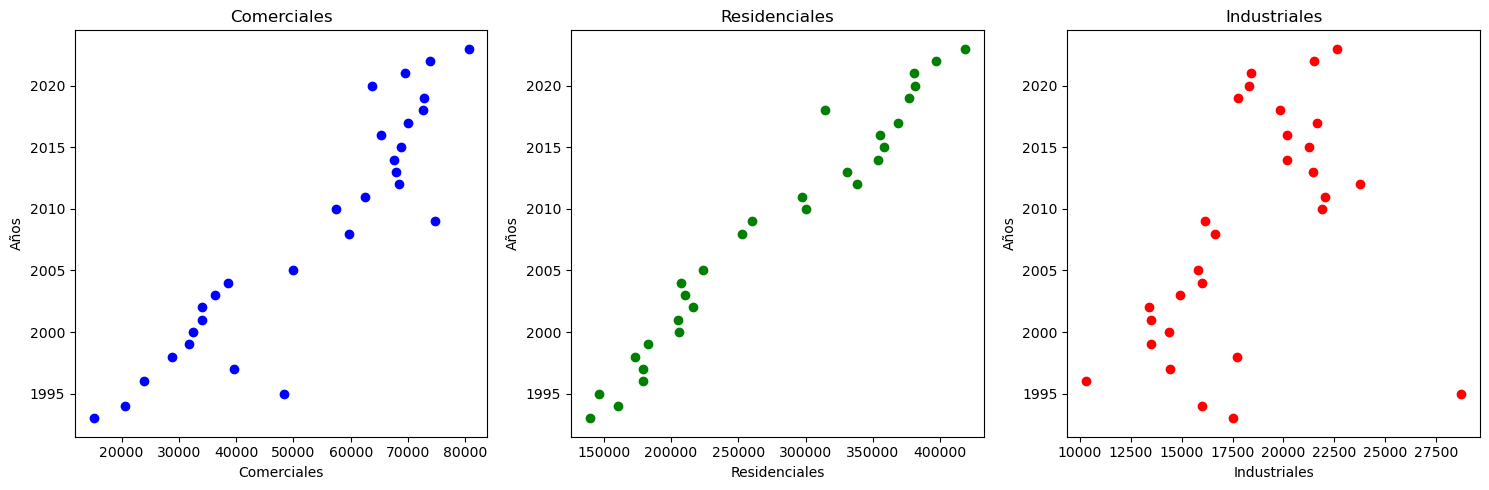

In [49]:
# Visualización de la relación de cada variable independiente con los años
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(X['Comerciales'], y, color='blue')
plt.title('Comerciales')
plt.xlabel('Comerciales')
plt.ylabel('Años')

plt.subplot(1, 3, 2)
plt.scatter(X['Residenciales'], y, color='green')
plt.title('Residenciales')
plt.xlabel('Residenciales')
plt.ylabel('Años')

plt.subplot(1, 3, 3)
plt.scatter(X['Industriales'], y, color='red')
plt.title('Industriales')
plt.xlabel('Industriales')
plt.ylabel('Años')

plt.tight_layout()
plt.show()

##### Comerciales y Residenciales muestran una tendencia de crecimiento consistente en el consumo a lo largo de los años, mientras que Industriales presenta mayor variabilidad. Esto podría implicar que los sectores comerciales y residenciales tienen una demanda de gas más predecible y en aumento continuo, mientras que el sector industrial podría estar influenciado por factores más dinámicos, como la producción industrial

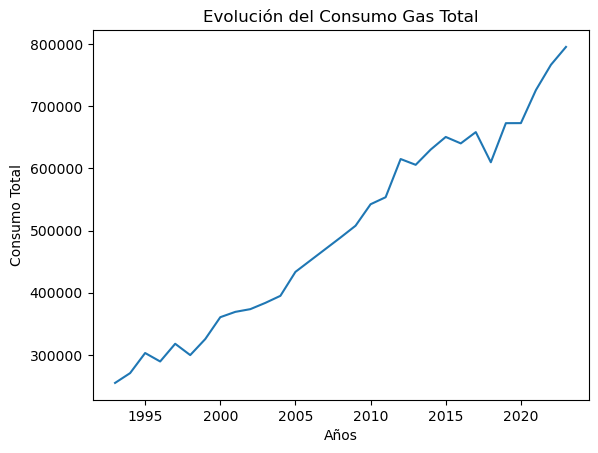

In [51]:
# Crear un gráfico de línea del consumo total
plt.plot(df['Años'], df['Total'])
plt.xlabel('Años')
plt.ylabel('Consumo Total')
plt.title('Evolución del Consumo Gas Total')
plt.show()

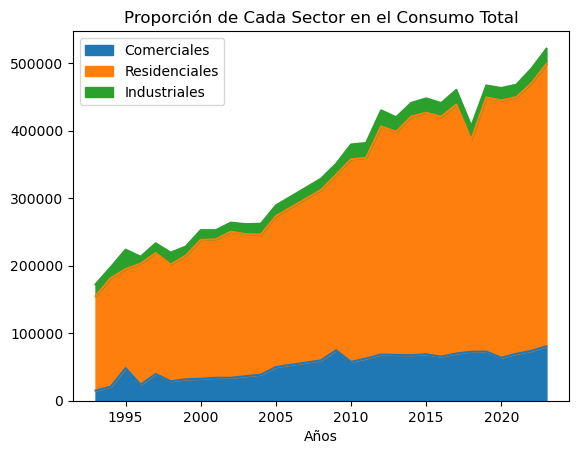

In [53]:
# Crear un gráfico de área apilada para la proporción de cada sector
df.plot(x='Años', y=['Comerciales', 'Residenciales', 'Industriales'], kind='area', stacked=True)
plt.title('Proporción de Cada Sector en el Consumo Total')
plt.show()

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separar variables dependiente e independiente
X = df[['Años']]  # Años
y = df['Comerciales']  # Consumo Comercial

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")

# Predicción para el año 2024
prediccion_2024 = modelo.predict(np.array([[2024]]))
print(f"Predicción para 2024: {prediccion_2024}")

MSE: 23978151.830807958
R²: 0.9064205170628011
Predicción para 2024: [83128.81194948]


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##### El modelo predice que el consumo comercial para el año 2024 será de aproximadamente 83,129 m3 unidades de gas (la unidad exacta depende de cómo estén representados los datos). Esto sugiere un crecimiento continuo en el consumo comercial para ese año.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separar variables dependiente e independiente
X = df[['Años']]  # Años
y = df['Residenciales']  # Consumo Residencial

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")

# Predicción para el año 2024
prediccion_2024 = modelo.predict(np.array([[2024]]))
print(f"Predicción para 2024: {prediccion_2024}")

MSE: 118828080.492858
R²: 0.9793143829100117
Predicción para 2024: [417902.56928287]


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##### El modelo predice que el consumo residencial de gas en 2024 será de aproximadamente 417,902 m3 unidades de gas. Este valor representa un incremento constante y significativo en comparación con años anteriores.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separar variables dependiente e independiente
X = df[['Años']]  # Años
y = df['Industriales']  # Consumo Industrial

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

# Realizar predicciones
y_pred = modelo.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R²: {r2}")

# Predicción para el año 2024
prediccion_2024 = modelo.predict(np.array([[2024]]))
print(f"Predicción para 2024: {prediccion_2024}")

MSE: 8404184.880720405
R²: 0.4266024101417998
Predicción para 2024: [20831.56629134]


C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


##### El modelo predice que el consumo industrial de gas en 2024 será de aproximadamente 20,831 m3 unidades de gas. Este valor representa un incremento constante y significativo en comparación con años anteriores.